In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from google.colab import files
import os

In [ ]:
# Create directory for saving models if it doesn't exist
os.makedirs('/content/resources/data', exist_ok=True)

In [ ]:
# Load the MNIST dataset
mnist_data = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist_data.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Define image dimensions
image_height, image_width = 28, 28

In [ ]:
# Reshape data to 4D for convolutional layers
train_images = train_images.reshape(train_images.shape[0], image_height, image_width, 1)
test_images = test_images.reshape(test_images.shape[0], image_height, image_width, 1)
input_dimensions = (image_height, image_width, 1)

In [ ]:
# Normalize pixel values to [0, 1] and set to float32
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

In [ ]:
# One-hot encode the labels
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)

In [ ]:
# Build a simple convolutional model with correct input shape
cnn_model = tf.keras.Sequential([
    tf.keras.Input(shape=input_dimensions),
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=10, activation='softmax')
])


In [ ]:
# Display model summary
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Train the model
training_epochs = 15
batch_size_value = 64
training_history = cnn_model.fit(
    train_images,
    train_labels,
    epochs=training_epochs,
    batch_size=batch_size_value,
    verbose=1
)


Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - accuracy: 0.8496 - loss: 0.4987
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9806 - loss: 0.0654
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9847 - loss: 0.0479
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9887 - loss: 0.0359
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9909 - loss: 0.0299
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9935 - loss: 0.0221
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.9945 - loss: 0.0186
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9952 - loss: 0.0157
Epoch 9/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.9956 - loss: 0.0140
Epoch 10/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.9969 - loss: 0.0109
Epoch 11/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.9973 - loss: 0.0075
Epoch 12/15
938/938 ━━━━━━━━━━

In [ ]:
# Evaluate the model
test_loss, test_accuracy = cnn_model.evaluate(test_images, test_labels)
print('Test Accuracy:', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9898 - loss: 0.0384
Test Accuracy: 0.9918000102043152


In [ ]:
# Save the trained model in all formats

cnn_model.save('/content/model.keras')

In [ ]:
# Download the model.keras file in Colab
files.download('/content/model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Model Prediction: 8


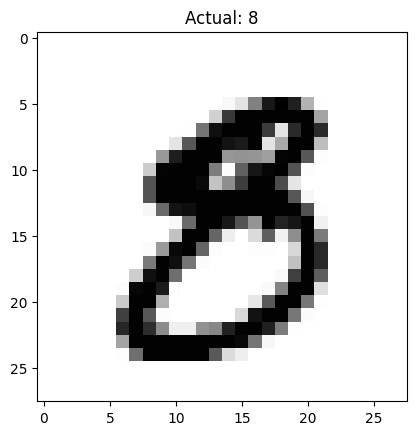

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Model Prediction: 1


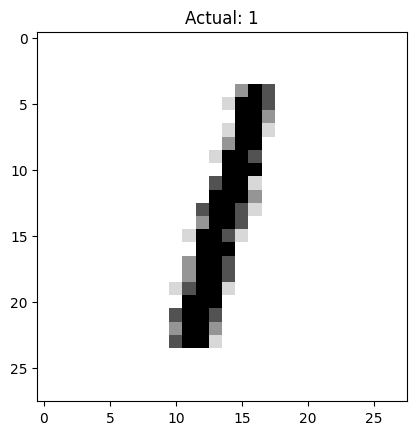

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Model Prediction: 5


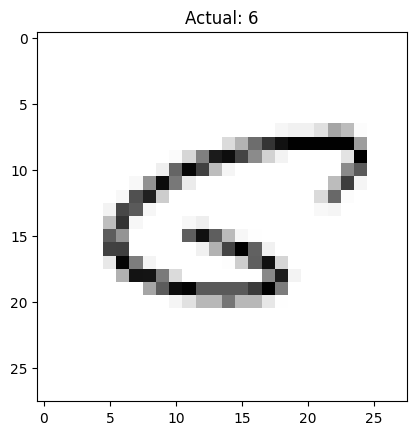

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Model Prediction: 4


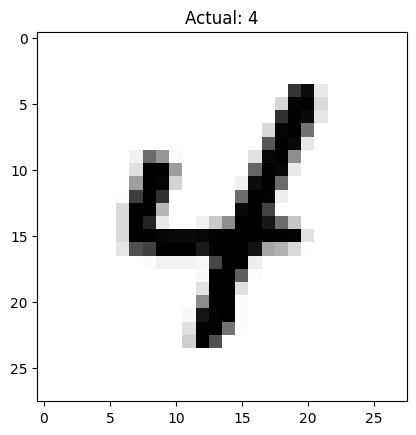

In [ ]:
# Predict and display for a few test images
images_to_show = 4
for idx in range(images_to_show):
    random_index = np.random.randint(0, len(test_images))
    plt.imshow(test_images[random_index].reshape(28, 28), cmap='Greys')
    plt.title(f"Actual: {np.argmax(test_labels[random_index])}")
    prediction = cnn_model.predict(test_images[random_index].reshape(1, image_height, image_width, 1))
    print(f"Model Prediction: {prediction.argmax()}")
    plt.show()


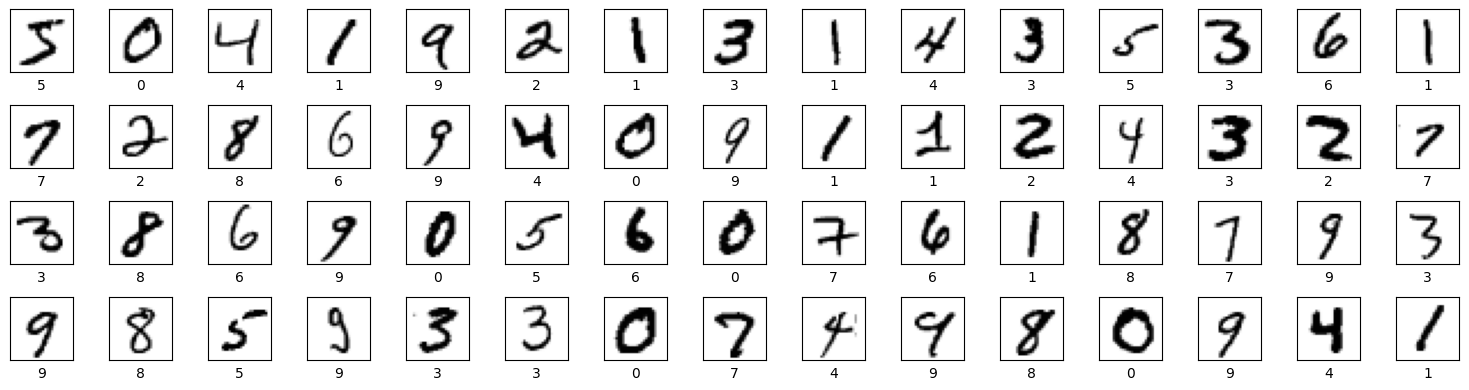

In [ ]:
# Display a grid of training images
grid_rows = 4
grid_cols = 15
plt.figure(figsize=(15, 4))
image_counter = 0
for row in range(grid_rows):
    for col in range(grid_cols):
        plt.subplot(grid_rows, grid_cols, image_counter + 1)
        plt.imshow(train_images[image_counter], cmap=plt.cm.gray_r)
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(np.argmax(train_labels[image_counter]))
        image_counter += 1
plt.tight_layout()
plt.show()